# Notebook 4 — Evaluation: Base vs Fine-Tuned Model
Computes ROUGE & BLEU scores and shows side-by-side qualitative comparisons.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/medical_qa_project')

In [3]:
!pip install -q transformers peft datasets evaluate rouge_score sacrebleu

In [4]:
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import evaluate, json, os

BASE_MODEL     = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
FT_MODEL_PATH  = "models/final_model"

# ── Load test set (raw, not tokenized) ──
raw_dataset = load_from_disk("dataset/medical_qa_raw")
# Re-create test split reference (same seed)
split1 = raw_dataset.train_test_split(test_size=0.2, seed=42)
split2 = split1["test"].train_test_split(test_size=0.5, seed=42)
test_raw = split2["test"]
print(f"Test examples: {len(test_raw)}")

Test examples: 100


In [5]:
# ── Load base model ──
base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
print("Base model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Base model loaded.


In [6]:
# ── Load fine-tuned model ──
ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_PATH)
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model = AutoModelForCausalLM.from_pretrained(FT_MODEL_PATH)
print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [7]:
# ── Inference function ──
def generate(tokenizer, model, question, max_new_tokens=150):
    prompt = f"""### Instruction:
{question}
### Response:
"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=200)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()

In [8]:
# ── Run evaluation on first 50 test examples ──
rouge = evaluate.load("rouge")
bleu  = evaluate.load("sacrebleu")

predictions_base = []
predictions_ft   = []
references       = []

EVAL_SAMPLES = min(50, len(test_raw))
print(f"Evaluating on {EVAL_SAMPLES} examples...")

for i, row in enumerate(test_raw.select(range(EVAL_SAMPLES))):
    q   = row["instruction"]
    ref = row["output"]
    pb  = generate(base_tokenizer, base_model, q)
    pf  = generate(ft_tokenizer, ft_model, q)
    predictions_base.append(pb)
    predictions_ft.append(pf)
    references.append(ref)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{EVAL_SAMPLES} done")

print("Inference complete.")

Evaluating on 50 examples...
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
Inference complete.


In [9]:
# ── Compute ROUGE ──
rouge_base = rouge.compute(predictions=predictions_base, references=references)
rouge_ft   = rouge.compute(predictions=predictions_ft,   references=references)

bleu_base = bleu.compute(predictions=predictions_base, references=[[r] for r in references])
bleu_ft   = bleu.compute(predictions=predictions_ft,   references=[[r] for r in references])

print("\n=== RESULTS TABLE ===")
print(f"{'Metric':<15} {'Base Model':>12} {'Fine-Tuned':>12} {'Delta':>10}")
print("-"*52)
for key in ["rouge1","rouge2","rougeL"]:
    b = rouge_base[key]
    f = rouge_ft[key]
    print(f"{key:<15} {b:>12.4f} {f:>12.4f} {f-b:>+10.4f}")
bb = bleu_base["score"]/100
bf = bleu_ft["score"]/100
print(f"{'bleu':<15} {bb:>12.4f} {bf:>12.4f} {bf-bb:>+10.4f}")


=== RESULTS TABLE ===
Metric            Base Model   Fine-Tuned      Delta
----------------------------------------------------
rouge1                0.0273       0.0330    +0.0057
rouge2                0.0018       0.0000    -0.0018
rougeL                0.0265       0.0337    +0.0073
bleu                  0.0004       0.0064    +0.0060


In [10]:
# ── Save results CSV ──
import csv
os.makedirs("outputs", exist_ok=True)
with open("outputs/results_table.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Metric", "Base Model", "Fine-Tuned", "Delta"])
    for key in ["rouge1","rouge2","rougeL"]:
        b,ft_ = rouge_base[key], rouge_ft[key]
        w.writerow([key, f"{b:.4f}", f"{ft_:.4f}", f"{ft_-b:+.4f}"])
    w.writerow(["bleu", f"{bb:.4f}", f"{bf:.4f}", f"{bf-bb:+.4f}"])
print("Results saved to outputs/results_table.csv")

Results saved to outputs/results_table.csv


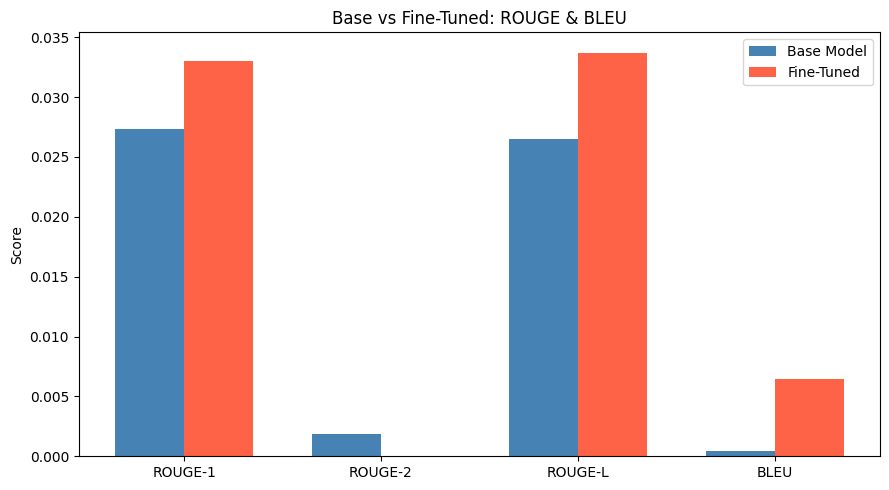

In [11]:
# ── Bar chart ──
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU"]
base_scores = [rouge_base["rouge1"], rouge_base["rouge2"], rouge_base["rougeL"], bb]
ft_scores   = [rouge_ft["rouge1"],   rouge_ft["rouge2"],   rouge_ft["rougeL"],   bf]

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - w/2, base_scores, w, label="Base Model", color="steelblue")
ax.bar(x + w/2, ft_scores,   w, label="Fine-Tuned", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score"); ax.set_title("Base vs Fine-Tuned: ROUGE & BLEU")
ax.legend(); plt.tight_layout()
plt.savefig("outputs/evaluation_comparison.png", dpi=150)
plt.show()

In [12]:
# ── Qualitative side-by-side examples ──
print("="*70)
print("QUALITATIVE COMPARISON (5 examples)")
print("="*70)
examples = []
for i in range(min(5, EVAL_SAMPLES)):
    q   = test_raw[i]["instruction"]
    ref = references[i]
    pb  = predictions_base[i]
    pf  = predictions_ft[i]
    examples.append({"question": q, "reference": ref,
                      "base_answer": pb, "finetuned_answer": pf})
    print(f"\n--- Example {i+1} ---")
    print(f"Q: {q[:120]}")
    print(f"\nBase   : {pb[:200]}")
    print(f"FT     : {pf[:200]}")
    print(f"Ref    : {ref[:200]}")

with open("outputs/qualitative_examples.json","w") as f:
    json.dump(examples, f, indent=2)
print("\nQualitative examples saved.")

QUALITATIVE COMPARISON (5 examples)

--- Example 1 ---
Q: Please answer with one of the option in the bracket

Base   : Option 1:
- Create a new folder named "assistant" in the root directory of your project.
- Open the "assistant" folder in your text editor.
- Add a new file named "index.html" to the "assistant" folde
FT     : B: Increased serum creatinine
Ref    : D: Decreased cardiac contractility due to cardiac myocyte injury

--- Example 2 ---
Q: Please answer with one of the option in the bracket

Base   : Option 1:
- Create a new folder named "assistant" in the root directory of your project.
- Open the "assistant" folder in your text editor.
- Add a new file named "index.html" to the "assistant" folde
FT     : D: Increased serum creatinine
Ref    : B: Impaired synthesis of cell wall polysaccharides

--- Example 3 ---
Q: Please answer with one of the option in the bracket

Base   : Option 1:
- Create a new folder named "assistant" in the root directory of your project.
- Open th